In [1]:
from sklearn.datasets import load_iris

flowers = load_iris()

print("Number of flowers:", len(flowers.data))
print("Measurements:", flowers.feature_names)
print("Flower types:", flowers.target_names)

Number of flowers: 150
Measurements: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Flower types: ['setosa' 'versicolor' 'virginica']


In [2]:
print("First flower's measurements:", flowers.data[0])

category_number = flowers.target[0]

print("Category number:", category_number)
print("Actual flower type:", flowers.target_names[category_number])

First flower's measurements: [5.1 3.5 1.4 0.2]
Category number: 0
Actual flower type: setosa


In [3]:
from sklearn.model_selection import train_test_split

training_measurements, testing_measurements, training_answers, testing_answers = train_test_split(
    flowers.data,
    flowers.target,
    test_size=0.2,
    random_state=42,
    stratify=flowers.target
)

print("Flowers for training:", len(training_measurements))
print("Flowers for testing:", len(testing_measurements))

Flowers for training: 120
Flowers for testing: 30


In [4]:
from sklearn.tree import DecisionTreeClassifier

flower_model = DecisionTreeClassifier(random_state=42)

flower_model.fit(training_measurements, training_answers)

print("Training complete.")

Training complete.


In [5]:
predicted_answers = flower_model.predict(testing_measurements)

print("Model's predictions:", predicted_answers)
print("Actual answers:     ", testing_answers)

Model's predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
Actual answers:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [6]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(testing_answers, predicted_answers)
correct_count = sum(testing_answers == predicted_answers)

print("Correct predictions:", correct_count, "out of", len(testing_answers))
print(f"Accuracy: {accuracy:.1%}")

Correct predictions: 28 out of 30
Accuracy: 93.3%


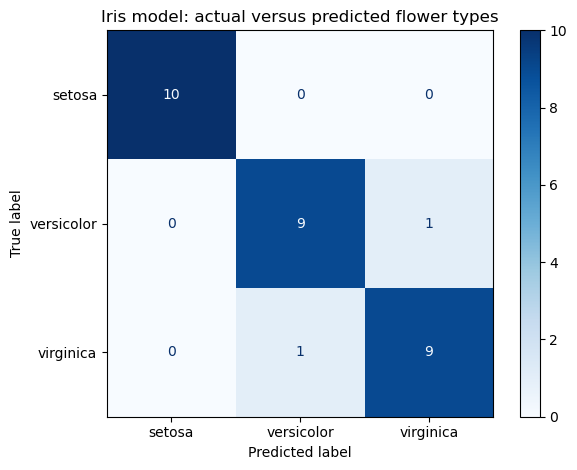

In [10]:
from pathlib import Path

output_folder = Path("../outputs")
output_folder.mkdir(exist_ok=True)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    testing_answers,
    predicted_answers,
    display_labels=flowers.target_names,
    cmap="Blues"
)

plt.title("Iris model: actual versus predicted flower types")
plt.tight_layout()
plt.savefig(output_folder / "confusion_matrix.png", dpi=150)
plt.show()

In [11]:
chart_file = output_folder / "confusion_matrix.png"

print("Saved file:", chart_file.resolve())
print("File exists:", chart_file.exists())

Saved file: C:\Users\User\Desktop\AIPROJECT\iris-classifier\outputs\confusion_matrix.png
File exists: True


## Results and interpretation

This project uses a decision-tree classifier to identify three Iris flower
types from four measurements.

The dataset contains 150 flowers. We used 120 for training and reserved
30 for testing, keeping the flower-type proportions balanced.

The model correctly classified 28 of the 30 test flowers, giving 93.3% accuracy.

The confusion matrix shows:
- All 10 Setosa flowers were classified correctly.
- One Versicolor flower was predicted as Virginica.
- One Virginica flower was predicted as Versicolor.

The test flowers were excluded from training. This score describes
performance on this test set; performance on other flowers may differ.